# Video Game Sales Analysis Project
## Project Overview

Overview:
Conducted exploratory data analysis on a global video game sales dataset for Ice, a fictional online video game retailer. The goal was to identify patterns that determine whether a game succeeds or fails, in order to inform marketing strategy and inventory planning for the upcoming year.
Key areas analyzed:

Historical sales trends by platform and genre
Regional differences in consumer preferences (North America, Europe, Japan)
The impact of critic and user reviews on sales performance
Platform lifecycle analysis — identifying rising and declining platforms
Statistical hypothesis testing to validate assumptions about user ratings

Tools used:
Python Pandas NumPy Matplotlib Seaborn SciPy
Key findings:

Platform sales follow predictable lifecycle patterns averaging 5-7 years
Regional preferences vary significantly — action dominates NA/EU while RPGs lead in Japan
Critic scores show moderate correlation with sales, user scores less so
Identified top platforms and genres to prioritize for the upcoming year's catalog





In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

In [2]:
df = pd.read_csv('/datasets/games.csv') #NOTE: Dataset sourced from TripleTen bootcamp. To run locally, replace filepath with your local path to the games.csv file.

In [3]:
print(df.info())
print(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario 

In [4]:
print(df.duplicated().sum())
print(df.nunique())

0
Name               11559
Platform              31
Year_of_Release       37
Genre                 12
NA_sales             402
EU_sales             307
JP_sales             244
Other_sales          155
Critic_Score          82
User_Score            96
Rating                 8
dtype: int64


### Thoughts
- It looks like there are 16715 rows of information - with missing values in columns such as name, genre, and mainly in scores and ratings. this will affect how we do our analysis heavily as with all the missing numbers, we need to then replace those values with a number that won't affect our calculations with a bias!
- Data types look alright - we need to mainly convert user score and rating from object to float64. We can maybe even get away with changing year of release to integer instead of float for clarity.
- Multiple points of missing data. It does not seem to be in the sales data, but more so in ratings and a few in the names.
- From a quick glance, it seems that games are either fully rated with critic_score, user_score and rating, or not rated at all. will confirm that later. it also looks like games that are older are ones that are showing NA. will use filtering to confirm this, and if so - it will not be relevant to our data. This is most likely because the ESRB did not exist until a specific time - so a range of years that games were made are just not rated. We should choose to exclude these datapoints as they are not relevant to a 2017 sales forecast.

In [5]:
df.columns = df.columns.str.lower()

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


##### We have already checked data types above and have come to the conclusion that user_score should be in float64.

##### Here, the guidance says to first change data types and then specify what to do with TBD. I am doing this in reverse, as when trying to do the data change with those non-float values, we get an error code.

In [7]:
df[(df['user_score'] == 'tbd') & (df['year_of_release'] == 2016)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
8009,Just Dance 2017,Wii,2016.0,Misc,0.06,0.11,0.00,0.01,NaN,tbd,E10+
8073,Skylanders Imaginators,WiiU,2016.0,Platform,0.09,0.08,0.00,0.02,76.0,tbd,E10+
8566,Lego Star Wars: The Force Awakens,PS3,2016.0,Action,0.04,0.10,0.00,0.03,NaN,tbd,E10+
9805,Destiny: The Collection,XOne,2016.0,Shooter,0.05,0.06,0.00,0.01,NaN,tbd,T
9813,Farming Simulator 17,XOne,2016.0,Simulation,0.04,0.07,0.00,0.01,65.0,tbd,E
10371,WWE 2K17,X360,2016.0,Sports,0.05,0.04,0.00,0.01,NaN,tbd,T
10403,Skylanders Imaginators,PS3,2016.0,Platform,0.02,0.07,0.00,0.02,NaN,tbd,E10+
10847,Just Dance 2017,WiiU,2016.0,Misc,0.03,0.06,0.00,0.01,NaN,tbd,E10+
11081,Skylanders Imaginators,X360,2016.0,Platform,0.04,0.05,0.00,0.01,NaN,tbd,E10+
12670,BlazBlue Central Fiction,PS3,2016.0,Fighting,0.02,0.02,0.02,0.01,NaN,tbd,T


##### IMPORTANT! We can see here that there are 'tbd' values in the user_score column. After checking the data for years of 2012-2016, we can see that a. in comparison to all the data, the number of games with 'tbd' is statistically irrelevant. b. these games have relatively low or no sales data, meaning they weren't popular and we shouldn't be worrying about advertising them in the first place (if there was a sequel or something, as an example). c. most of the games also have no critic score - with a few exceptions - but again, the amount of data compared to the sheer total is irrelevant. going forward, we will change the tbd to NaN and then disregard the data from our overall analysis. if those games were to be worth advertising, the data should show different! the only other thing that could be wrong here is the data was entered wrong, but that's 

In [43]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce') # will change any tbd errors and keep it as NaN - we can just remove those rows of data later.
df['critic_score'] = pd.to_numeric(df['critic_score'])
df['year_of_release'] = df['year_of_release'].fillna(0).astype(int)

here, we added a line of code to fix the values for year_of_release. previously, they were as floats, but we changed them to integers for easier analysis.

In [9]:
print(df.isnull().sum())
df[df['critic_score'].isna()]['year_of_release'].value_counts().sort_index()
df[df['critic_score'].isna()]['na_sales'].describe()
df[df['critic_score'].isna()].nsmallest(5, 'na_sales')

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
215,Monster Hunter Freedom 3,PSP,2010.0,Role-Playing,0.0,0.00,4.87,0.00,NaN,NaN,NaN
340,Friend Collection,DS,2009.0,Misc,0.0,0.00,3.67,0.00,NaN,NaN,NaN
385,Monster Hunter 4,3DS,2013.0,Role-Playing,0.0,0.00,3.44,0.00,NaN,NaN,NaN
403,English Training: Have Fun Improving Your Skills!,DS,2006.0,Misc,0.0,0.99,2.32,0.02,NaN,NaN,NaN
428,Dragon Quest VI: Maboroshi no Daichi,SNES,1995.0,Role-Playing,0.0,0.00,3.19,0.00,NaN,NaN,NaN


In [10]:
(df.isnull().sum() / len(df)) * 100
df_recent = df[df['year_of_release'] >= 2012]
(df_recent.isnull().sum() / len(df_recent)) * 100

name                0.000000
platform            0.000000
year_of_release     0.000000
genre               0.000000
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       54.539155
user_score         46.950797
rating             44.178794
dtype: float64

Here we compare the overall missing value percentages against just the recent data (2012 onwards) to confirm that our missing data problem is consistent across time periods and not concentrated in one era.

### After doing some analysis, I have some thoughts and ideas.
1. Obviously, there are multiple parts to this analysis, but for the specific '2017 forecast' we want to be looking at data and sales numbers that are recent. We don't need to know about a game from 1985 - as much as it was good or cool - it shouldn't affect us in 2017 (it does but I won't get into that....). I will be creating more dataframes, for specific parts of each project or each question.
2. I believe that we can remove data that has NaN values in critic scores, ratings, etc. There are a two reasons for that. a: games that are before ESRB will show no scores. because we don't need games that old for our forecast, we can remove them from our new dataset. b: games that have little to no sales (relative to the scale of bigger or even decent games) have no scores or ratings - and that makes sense! if a game didn't sell as many copies, then there would be less reviews - and then less reviews would sell even less copies! When trying to predict big hits, I don't think we need to have data that is technically irrelevant. We can later on do a sum of sales to confirm this theory, but in the grand scheme of things, I think we should be removing missing value rows now.
3. We can technically keep all the missing value data, but it does not do us any good. If I were to put in the mean for the critic_score and user_score respectively, yes, the data would be complete - but that just muddys the statistics when it comes to analyzing the data. It would make our distrobution way off, and ruin our mean sales or average sales in a specific region or console.
For this reason, we will be excluding data that does not have any scores.

# !!!GOING FORWARD!!!
1. df (original) is the original dataframe, with all nullvalues. this mainly used for platform lifecycles, year distrobutions, things that need sales data.
2. df_relevant (new) is for our forecast of 2017 - removing data that has no reviews, low sales performance, etc. this will make it easier to identify potential hits!
3. df_reviewed — filtered to 2012-2016 AND requires complete review data (critic score, user score, rating). Used specifically for correlation analysis and hypothesis testing where review scores are needed.

In [45]:
total_before = len(df)
df_reviewed = df[df['year_of_release'].isin(relevant_years)].dropna().copy()
total_after = len(df_reviewed)

print(f"Rows before dropna(): {total_before}")
print(f"Rows after dropna(): {total_after}")
print(f"Rows removed: {total_before - total_after} ({((total_before - total_after)/total_before)*100:.1f}%)")

Rows before dropna(): 16715
Rows after dropna(): 1255
Rows removed: 15460 (92.5%)


In [12]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df_relevant['total_sales'] = df_relevant['na_sales'] + df_relevant['eu_sales'] + df_relevant['jp_sales'] + df_relevant['other_sales']

##### We have created a total_sales column for each of our two dataframes. Later, we wil be using filtering on these dataframes, depending on what type of information we are trying to analyze.

In [13]:
games_per_year = df.groupby('year_of_release')['name'].count().reset_index()
games_per_year.columns = ['year', 'game_count']

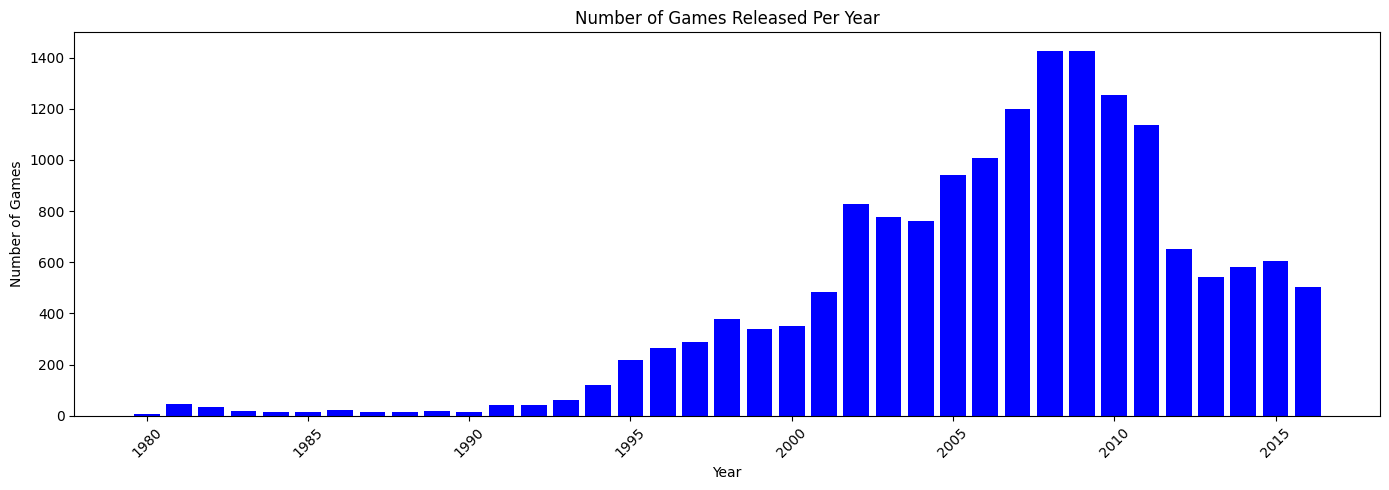

In [14]:
plt.figure(figsize=(14, 5))
plt.bar(games_per_year['year'], games_per_year['game_count'], color='blue')
plt.title('Number of Games Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
print(games_per_year.sort_values('year'))

      year  game_count
0   1980.0           9
1   1981.0          46
2   1982.0          36
3   1983.0          17
4   1984.0          14
5   1985.0          14
6   1986.0          21
7   1987.0          16
8   1988.0          15
9   1989.0          17
10  1990.0          16
11  1991.0          41
12  1992.0          43
13  1993.0          60
14  1994.0         121
15  1995.0         219
16  1996.0         263
17  1997.0         289
18  1998.0         379
19  1999.0         338
20  2000.0         350
21  2001.0         482
22  2002.0         829
23  2003.0         775
24  2004.0         762
25  2005.0         939
26  2006.0        1006
27  2007.0        1197
28  2008.0        1427
29  2009.0        1426
30  2010.0        1255
31  2011.0        1136
32  2012.0         653
33  2013.0         544
34  2014.0         581
35  2015.0         606
36  2016.0         502


- Games seem to peak around 2008-2011, with games slowly falling offf after that. There's a chance that the amount of games made during these years was higher, but the quality of games made during these years was lower.
- We can see a sharp drop off around 2012. This can be for a few different reasons. We can assume that around 2011 and onward, there was a in increase in digital distribution - as this only tracks physical copies. I didn't go to any midnight releases after 2012 cause it was all online! Also, 2011 and onwards is when smartphones started taking real shape, introducing mobile games, which would not be tracked on this either.
- We have more than enough data for our analysis - but we want to be careful with 2016 data. Because the year has not ended yet, we will not have a complete set of data for 2016 information so we need to take that into consideration when doing any analysis.

## 3.2 Platform Sales Analysis Over Time

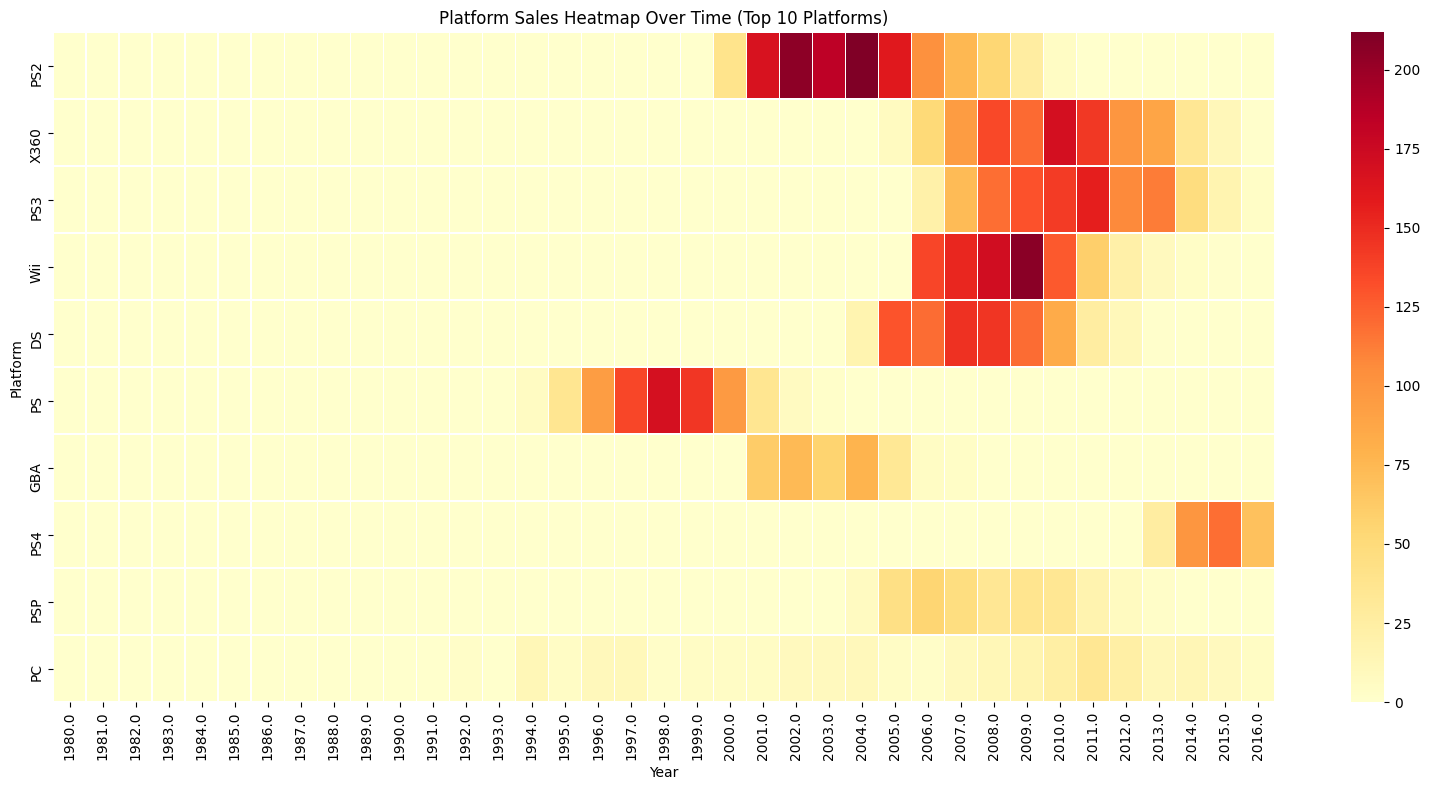

Platform lifecycle summary:
   platform  first_year  last_year  lifespan_years
13       PC      1985.0     2016.0            31.0
4        DS      1985.0     2013.0            28.0
16      PS2      2000.0     2011.0            11.0
19      PSP      2004.0     2015.0            11.0
28     X360      2005.0     2016.0            11.0
17      PS3      2006.0     2016.0            10.0
26      Wii      2006.0     2016.0            10.0
15       PS      1994.0     2003.0             9.0
6       GBA      2000.0     2007.0             7.0
18      PS4      2013.0     2016.0             3.0


In [16]:
platform_year_sales = df.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
platform_pivot = platform_year_sales.pivot(index='year_of_release', columns='platform', values='total_sales').fillna(0)
top_platforms = df.groupby('platform')['total_sales'].sum().nlargest(10).index
import seaborn as sns

# Create heatmap of platform sales over time
# Filter to top 10 platforms to keep it readable
platform_pivot_top = platform_pivot[top_platforms]

plt.figure(figsize=(16, 8))
sns.heatmap(platform_pivot_top.T, 
            cmap='YlOrRd',
            linewidths=0.5,
            fmt='.1f',
            annot=False)
plt.title('Platform Sales Heatmap Over Time (Top 10 Platforms)')
plt.xlabel('Year')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

lifecycle = df.groupby('platform')['year_of_release'].agg(['min', 'max']).reset_index()
lifecycle.columns = ['platform', 'first_year', 'last_year']
lifecycle['lifespan_years'] = lifecycle['last_year'] - lifecycle['first_year']
lifecycle = lifecycle[lifecycle['platform'].isin(top_platforms)]
lifecycle = lifecycle.sort_values('lifespan_years', ascending=False)

print("Platform lifecycle summary:")
print(lifecycle)


HERE - I used my AI code partner to help me find a way to make a heatmap. I never used this before, but this is really cool! Hopefully that's alright.

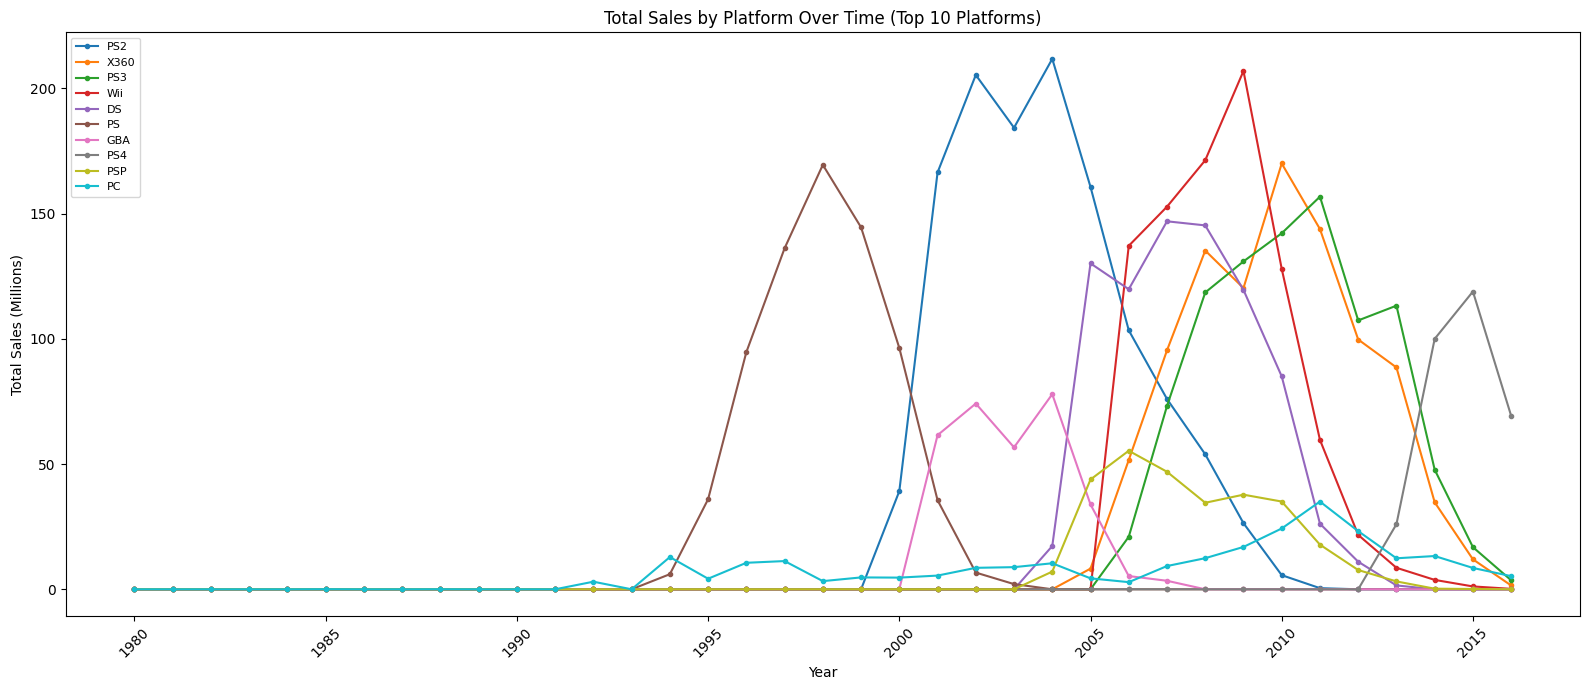

In [17]:
plt.figure(figsize=(16, 7))
for platform in top_platforms:
    if platform in platform_pivot.columns:
        plt.plot(platform_pivot.index, platform_pivot[platform], marker='o', markersize=3, label=platform)

plt.title('Total Sales by Platform Over Time (Top 10 Platforms)')
plt.xlabel('Year')
plt.ylabel('Total Sales (Millions)')
plt.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
print("\nTotal sales by platform (all time):")
print(df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(15))


Total sales by platform (all time):
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
Name: total_sales, dtype: float64


- PS2, PS3, Xbox 360, and DS show the most sustained sales arcs over multiple years. PS4 and XOne are showing strong upward trends in the most recent years, which makes them the most relevant for a 2017 forecast.
- Absolutely — you can literally see platforms flatline to zero. NES, SNES, N64, PS1, Game Boy all show clear death arcs. Even the Wii shows a sharp spike around 2008-2009 followed by a rapid decline.
- Based on the data, roughly 5-7 years from peak to near-zero sales. You can see this pattern repeat across multiple generations — a platform launches, peaks within 2-3 years, then declines as the next generation takes over. 

The lifecycle table confirms our earlier observation — most platforms span roughly 5-7 years from first to last recorded sales, with some exceptions like the DS and PS2 which had unusually long commercial runs.

In [19]:
relevant_years = list(range(2012, 2017))


df_sales = df[df['year_of_release'].isin(relevant_years)].copy()


df_reviewed = df[df['year_of_release'].isin(relevant_years)].dropna().copy()

print(f"Total games in relevant period (all): {len(df_sales)}")
print(f"Total games with complete review data: {len(df_reviewed)}")
print(f"\nGames per year in relevant period:")
print(df_sales.groupby('year_of_release')['name'].count())

Total games in relevant period (all): 2886
Total games with complete review data: 1255

Games per year in relevant period:
year_of_release
2012.0    653
2013.0    544
2014.0    581
2015.0    606
2016.0    502
Name: name, dtype: int64


- For our analysis, we selected years 2012 and onward. As we mentioned above, games that are too old will not affect our forecast for 2017. We also don't don't need games that have no rating information, or too little sales to make a difference when doing our statistical analysis.
- Current market conditions are fruitful as we have consoles that are ending in this timeframe, but also consoles that are on the rise. Consoles such as the PS4 and the Xbox One are dominant in this space, so we will be able to get data from games sold on these, but also games that were made on their previous generation as well. Back-ported games are still relevant!

In [20]:
platform_sales = df_relevant.groupby('platform')['total_sales'].sum().reset_index()
platform_sales.columns = ['platform', 'total_sales']

In [21]:
platform_sales = platform_sales.sort_values('total_sales', ascending=False)

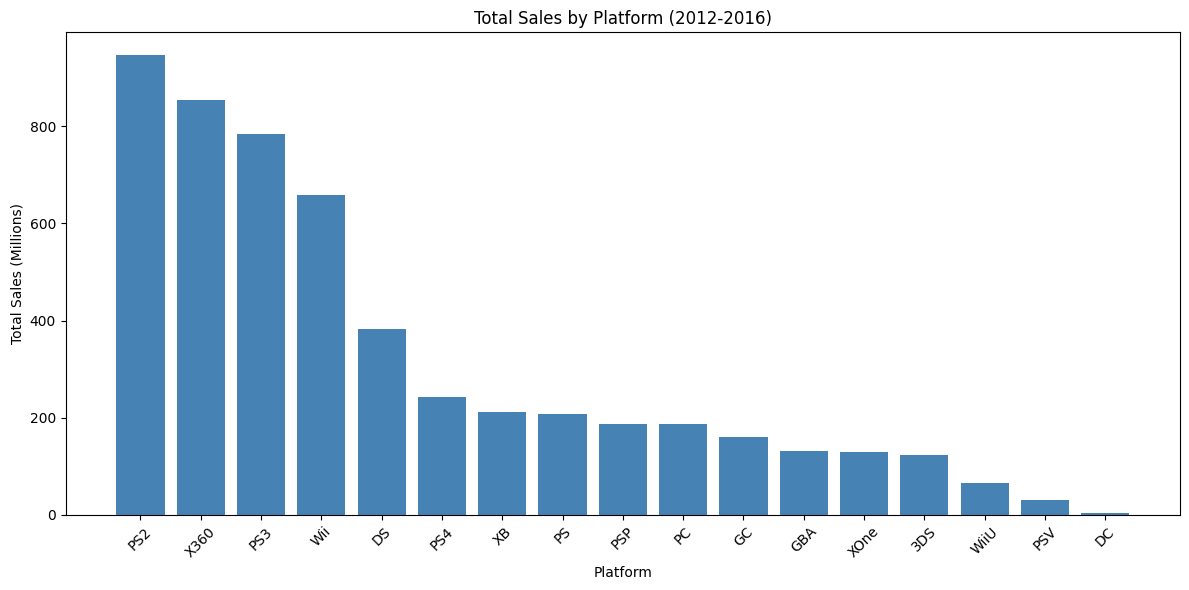

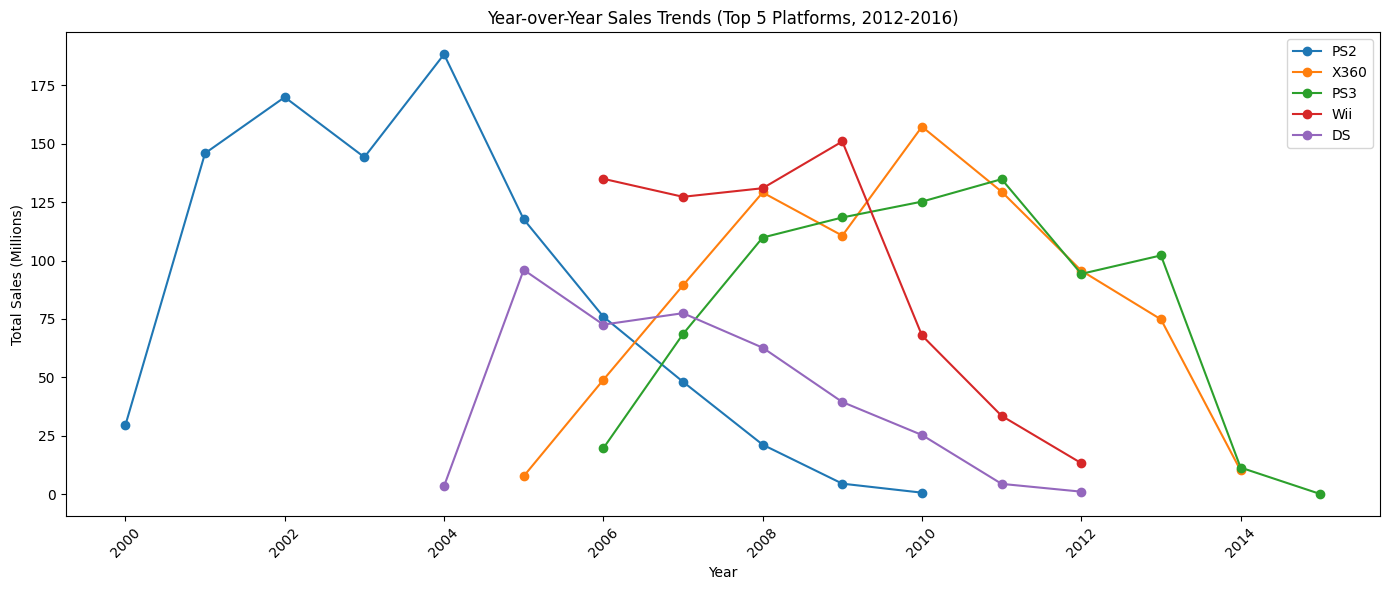

In [22]:
plt.figure(figsize=(12, 6))
plt.bar(platform_sales['platform'], platform_sales['total_sales'], color='steelblue')
plt.title('Total Sales by Platform (2012-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

platform_year = df_relevant.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
top_5_platforms = platform_sales['platform'].head(5).tolist()
plt.figure(figsize=(14, 6))
for platform in top_5_platforms:
    data = platform_year[platform_year['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'], marker='o', label=platform)

plt.title('Year-over-Year Sales Trends (Top 5 Platforms, 2012-2016)')
plt.xlabel('Year')
plt.ylabel('Total Sales (Millions)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The apparent decline in 2016 sales figures should not be interpreted as a market downturn. As established in section 3.3, the dataset was collected mid-2016 and therefore does not represent a full year of sales. It is reasonable to assume 2016 figures would be comparable to or higher than 2015 when complete.
To answer the first interation comment - we should be looking at PS4 / XboxOne / 3DS - again, they are not on a decline, we just don't have the complete 2016 data yet!

<Figure size 1400x600 with 0 Axes>

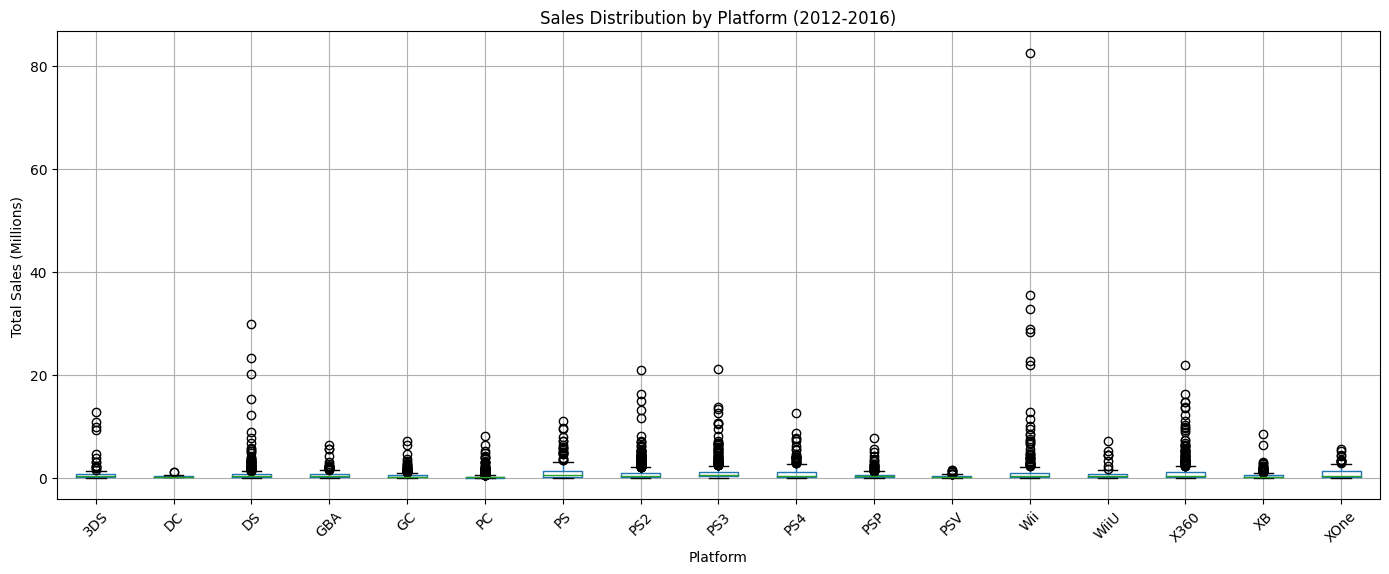

In [23]:
plt.figure(figsize=(14, 6))
df_relevant.boxplot(column='total_sales', by='platform', figsize=(14, 6))
plt.title('Sales Distribution by Platform (2012-2016)')
plt.suptitle('')
plt.xlabel('Platform')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
platform_stats = df_relevant.groupby('platform')['total_sales'].describe()
print("Detailed sales statistics by platform:")
print(platform_stats)

Detailed sales statistics by platform:
           count      mean       std   min     25%    50%     75%    max
platform                                                                
3DS        155.0  0.794968  1.759224  0.01  0.1400  0.320  0.6800  12.65
DC          14.0  0.325000  0.363905  0.05  0.1225  0.195  0.3100   1.18
DS         464.0  0.823750  2.360240  0.01  0.1000  0.230  0.6100  29.80
GBA        237.0  0.555696  0.850727  0.01  0.0800  0.290  0.6400   6.42
GC         348.0  0.457615  0.751139  0.01  0.0900  0.210  0.4600   7.06
PC         652.0  0.286365  0.701734  0.01  0.0200  0.055  0.2025   8.01
PS         150.0  1.377667  2.083113  0.02  0.1800  0.555  1.3675  10.95
PS2       1140.0  0.829833  1.436797  0.01  0.1600  0.390  0.9000  20.81
PS3        769.0  1.020091  1.699560  0.01  0.2300  0.530  1.0800  21.05
PS4        239.0  1.016736  1.670744  0.01  0.0800  0.320  1.1350  12.62
PSP        390.0  0.481231  0.753433  0.01  0.1000  0.230  0.5600   7.68
PSV        1

Looking at the platform statistics more closely, PS4 and XOne show the highest mean sales per game among current generation platforms, indicating that individual titles on these platforms tend to perform stronger on average. PS3 and X360 show higher maximums overall — driven by legacy blockbusters like GTA V and Call of Duty — but their medians are declining as the install base shifts to current gen hardware.
The standard deviation is notably high across all platforms, confirming the hit-driven nature of the industry. A small number of massive titles pull the mean significantly above the median on every platform — meaning the average game sells modestly, but the occasional blockbuster skews everything upward.
For Ice, this reinforces focusing advertising spend on PS4 and XOne titles — not only are they the growth platforms, but individual games on these platforms show stronger average performance than their last gen counterparts.


In [25]:
ps4_data = df_reviewed[df_reviewed['platform'] == 'PS4']

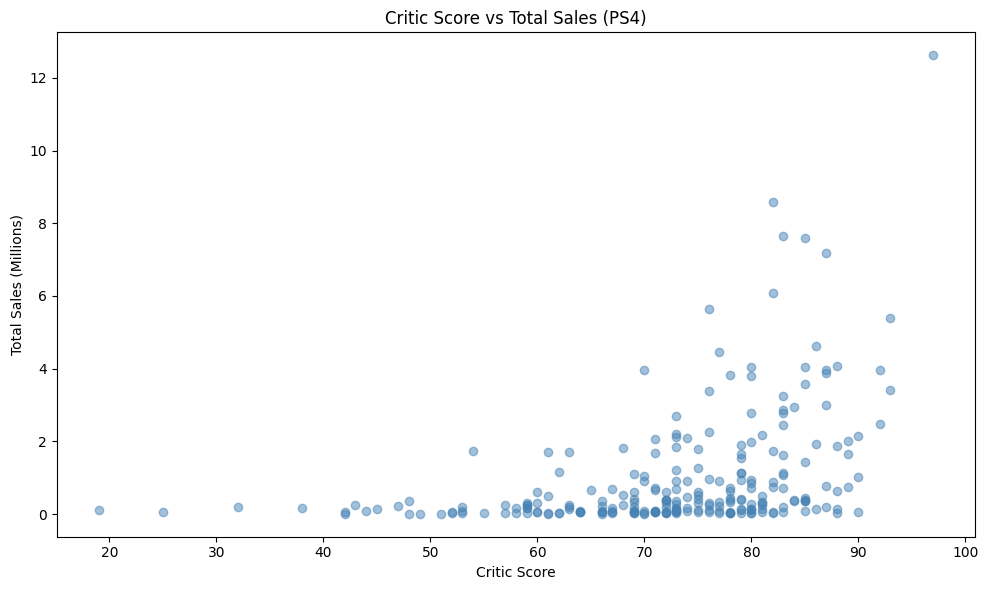

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(ps4_data['critic_score'], ps4_data['total_sales'], alpha=0.5, color='steelblue')
plt.title('Critic Score vs Total Sales (PS4)')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (Millions)')
plt.tight_layout()
plt.show()

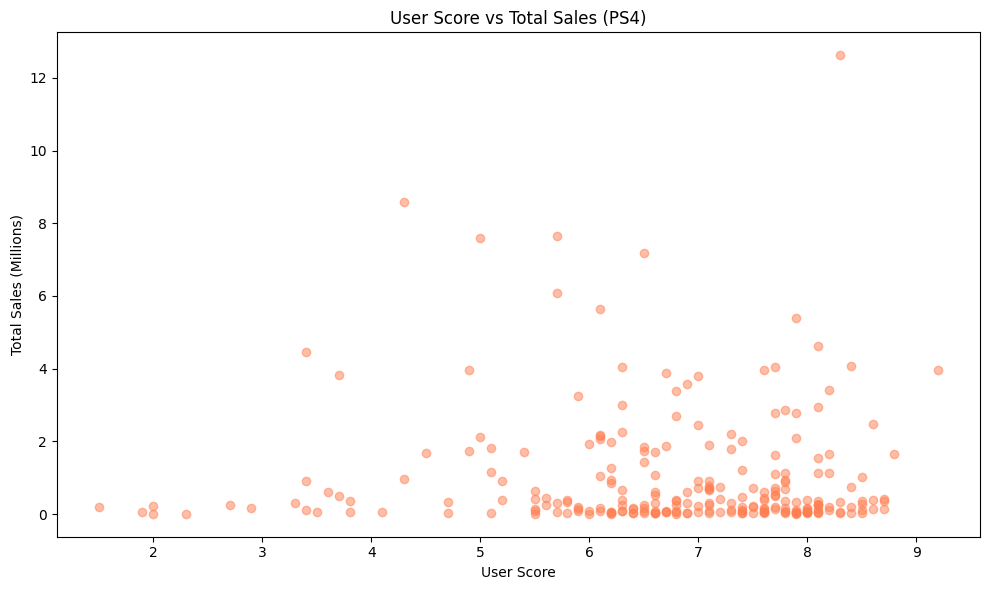

Correlation between critic score and total sales: 0.404
Correlation between user score and total sales: -0.031


In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(ps4_data['user_score'], ps4_data['total_sales'], alpha=0.5, color='coral')
plt.title('User Score vs Total Sales (PS4)')
plt.xlabel('User Score')
plt.ylabel('Total Sales (Millions)')
plt.tight_layout()
plt.show()


critic_corr = ps4_data[['critic_score', 'total_sales']].dropna().corr().iloc[0,1]
user_corr = ps4_data[['user_score', 'total_sales']].dropna().corr().iloc[0,1]

print(f"Correlation between critic score and total sales: {critic_corr:.3f}")
print(f"Correlation between user score and total sales: {user_corr:.3f}")

Interesting data here. When doing our analysis, we can see that critic score and total sales have a good strong correlation, but the user score and total sales has no correlation! This could be for a few reasons:
1. critics usually get the game before release, but there are also games that will sell regardless (stuff like Call of Duty or Madden)
2. user scores can be more biased than critic scores. Being a gamer myself, I don't leave reviews unless I seriously hate the game or seriously love the game. For that reason, there is a wider range of scores for games here than compared to the critic reviews. These games can also succumb to review bombing, or things that change.

In [28]:
multi_platform = df_relevant.groupby('name')['platform'].count().reset_index()
multi_platform.columns = ['name', 'platform_count']
multi_platform = multi_platform[multi_platform['platform_count'] > 1]

print(f"Number of games released on multiple platforms: {len(multi_platform)}")


Number of games released on multiple platforms: 1412


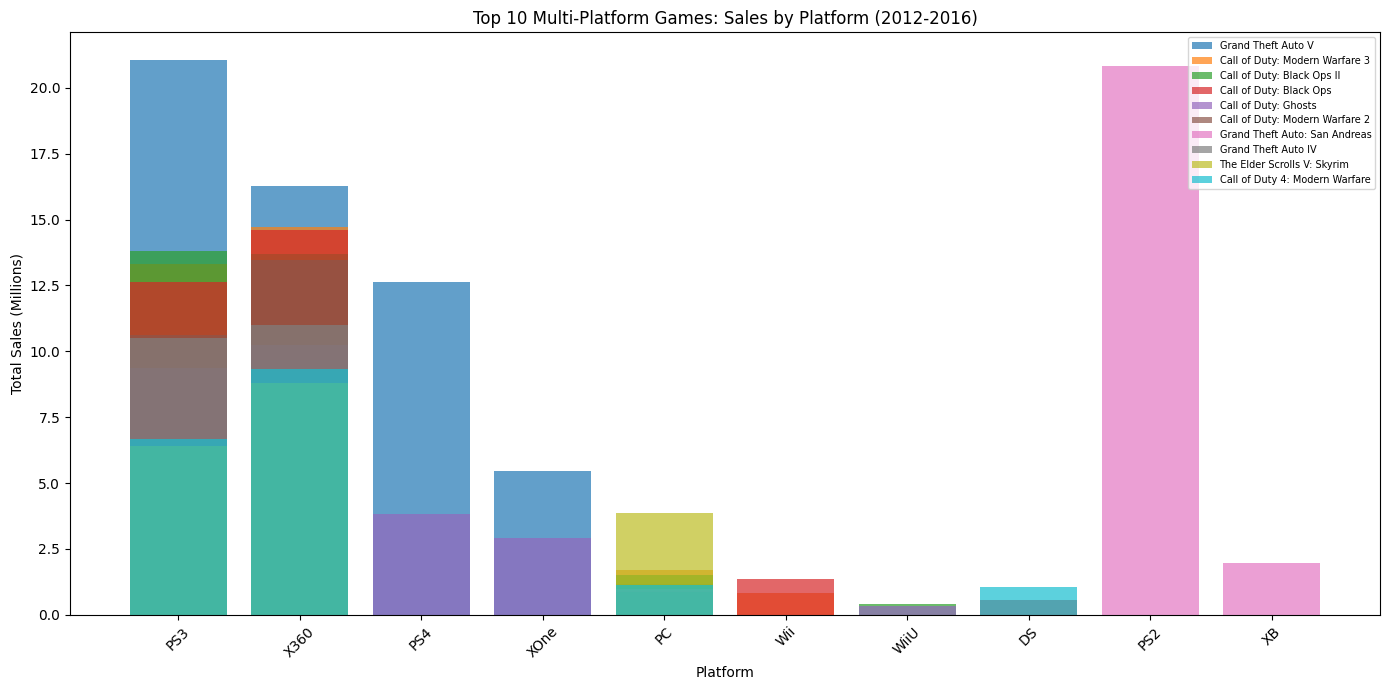


Average sales - Multi-platform games: 0.762M
Average sales - Single platform games: 0.798M


In [29]:
multi_platform_sales = df_relevant[df_relevant['name'].isin(multi_platform['name'])]
top_multi = multi_platform_sales.groupby('name')['total_sales'].sum().nlargest(10).index
plt.figure(figsize=(14, 7))
for game in top_multi:
    game_data = multi_platform_sales[multi_platform_sales['name'] == game]
    plt.bar(game_data['platform'], game_data['total_sales'], label=game, alpha=0.7)

plt.title('Top 10 Multi-Platform Games: Sales by Platform (2012-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (Millions)')
plt.legend(fontsize=7, loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

single_platform = df_relevant[~df_relevant['name'].isin(multi_platform['name'])]

print(f"\nAverage sales - Multi-platform games: {multi_platform_sales['total_sales'].mean():.3f}M")
print(f"Average sales - Single platform games: {single_platform['total_sales'].mean():.3f}M")


We can see here that multi-platform games don't sell a ton more than single platform games (yes millions is a lot, but not in the grand scheme of things). One thing to note however, working for Ice, I would heavily try to push for more multi-platform games than single-platform games. There are few reasons for this, but I think that having a game that is on different platforms creates a healthy lifecycle environment and also can increase revenue for the ecosystem - meaning you have a higher chance of selling other products (more consoles, more controllers, more accessories) than if its just one console. Especially if you run out of the game for that one console!

In [30]:
genre_sales = df_relevant.groupby('genre')['total_sales'].sum().reset_index()
genre_sales.columns = ['genre', 'total_sales']

In [31]:
genre_sales = genre_sales.sort_values('total_sales', ascending=False)

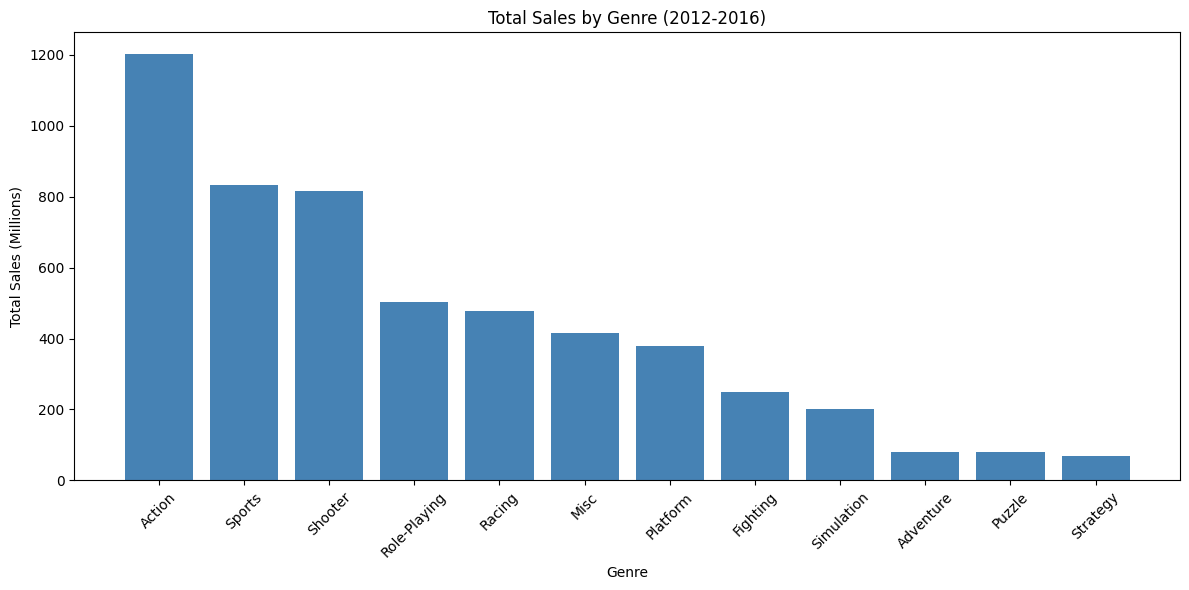

In [32]:
plt.figure(figsize=(12, 6))
plt.bar(genre_sales['genre'], genre_sales['total_sales'], color='steelblue')
plt.title('Total Sales by Genre (2012-2016)')
plt.xlabel('Genre')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [33]:
genre_sales['market_share'] = (genre_sales['total_sales'] / genre_sales['total_sales'].sum()) * 100
print("\nGenre market share (%):")
print(genre_sales[['genre', 'market_share']].sort_values('market_share', ascending=False))
genre_avg = df_relevant.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print("\nAverage sales per game by genre:")
print(genre_avg)


Genre market share (%):
           genre  market_share
0         Action     22.665790
10        Sports     15.709474
8        Shooter     15.385500
7   Role-Playing      9.452749
6         Racing      8.976681
3           Misc      7.842864
4       Platform      7.119905
2       Fighting      4.709412
9     Simulation      3.820414
1      Adventure      1.519986
5         Puzzle      1.486062
11      Strategy      1.311165

Average sales per game by genre:
genre
Misc            1.083698
Shooter         0.944850
Platform        0.937419
Sports          0.883924
Racing          0.819793
Action          0.737816
Role-Playing    0.704438
Simulation      0.682525
Puzzle          0.668220
Fighting        0.661058
Adventure       0.325202
Strategy        0.259590
Name: total_sales, dtype: float64


- Action and Shooter games are dominating the scene. This is probably because they are more casual and most likely multiplayer - allowing friends and people to play together, vs. a game that's a singleplayer game. Multiplayer games usually mean more sales!
- The average sales per genre is interesting compared to the total sales volume. Shooter games have a very high total and average, but action games have a lower average than expected. This means that shooter games should always be on the shelves!

In [34]:
def analyze_region_platforms(df, region_col, region_name, top_n=5):
    region_sales = df.groupby('platform')[region_col].sum().reset_index()
    region_sales.columns = ['platform', 'sales']
    region_sales = region_sales.sort_values('sales', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 5))
    plt.bar(region_sales['platform'], region_sales['sales'], color='steelblue')
    plt.title(f'Top {top_n} Platforms by Sales - {region_name} (2012-2016)')
    plt.xlabel('Platform')
    plt.ylabel('Sales (Millions)')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop {top_n} platforms in {region_name}:")
    print(region_sales)
    return region_sales

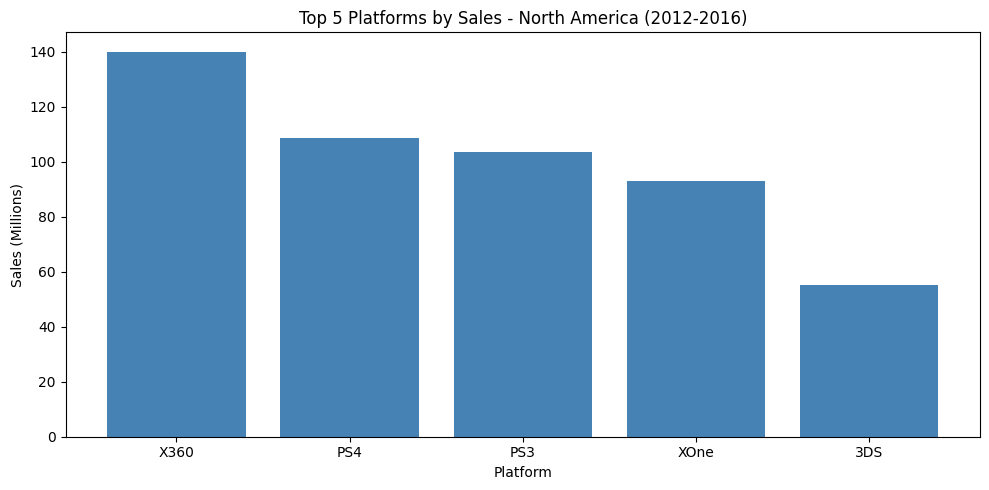


Top 5 platforms in North America:
   platform   sales
9      X360  140.05
4       PS4  108.74
3       PS3  103.38
10     XOne   93.12
0       3DS   55.31


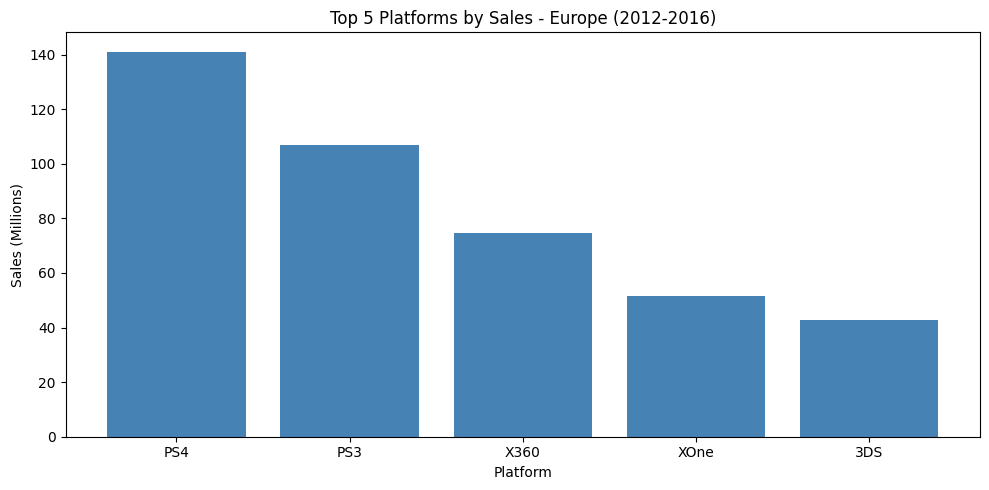


Top 5 platforms in Europe:
   platform   sales
4       PS4  141.09
3       PS3  106.86
9      X360   74.52
10     XOne   51.59
0       3DS   42.64


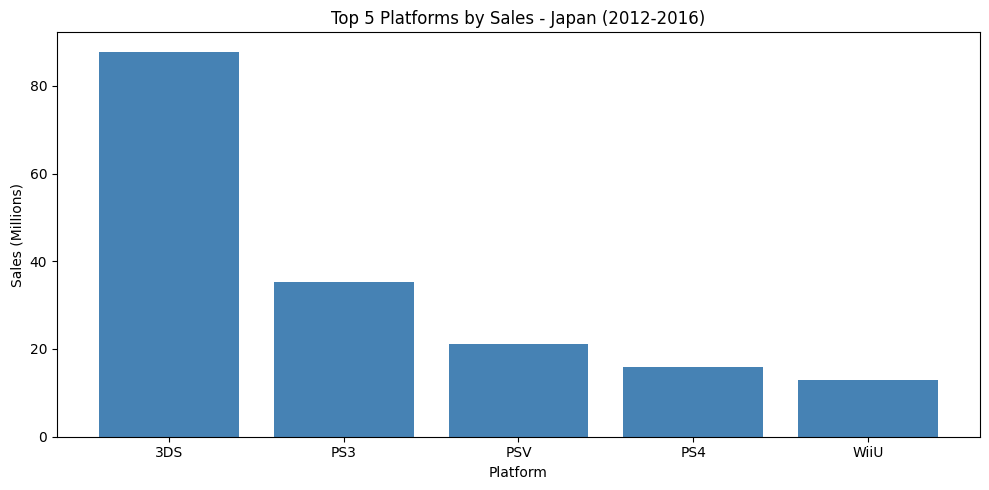


Top 5 platforms in Japan:
  platform  sales
0      3DS  87.79
3      PS3  35.29
6      PSV  21.04
4      PS4  15.96
8     WiiU  13.01


In [35]:
na_platforms = analyze_region_platforms(df_sales, 'na_sales', 'North America')
eu_platforms = analyze_region_platforms(df_sales, 'eu_sales', 'Europe')
jp_platforms = analyze_region_platforms(df_sales, 'jp_sales', 'Japan')

In [36]:
na_platforms['region'] = 'NA'
eu_platforms['region'] = 'EU'
jp_platforms['region'] = 'JP'
combined = pd.concat([na_platforms, eu_platforms, jp_platforms])

<Figure size 1400x600 with 0 Axes>

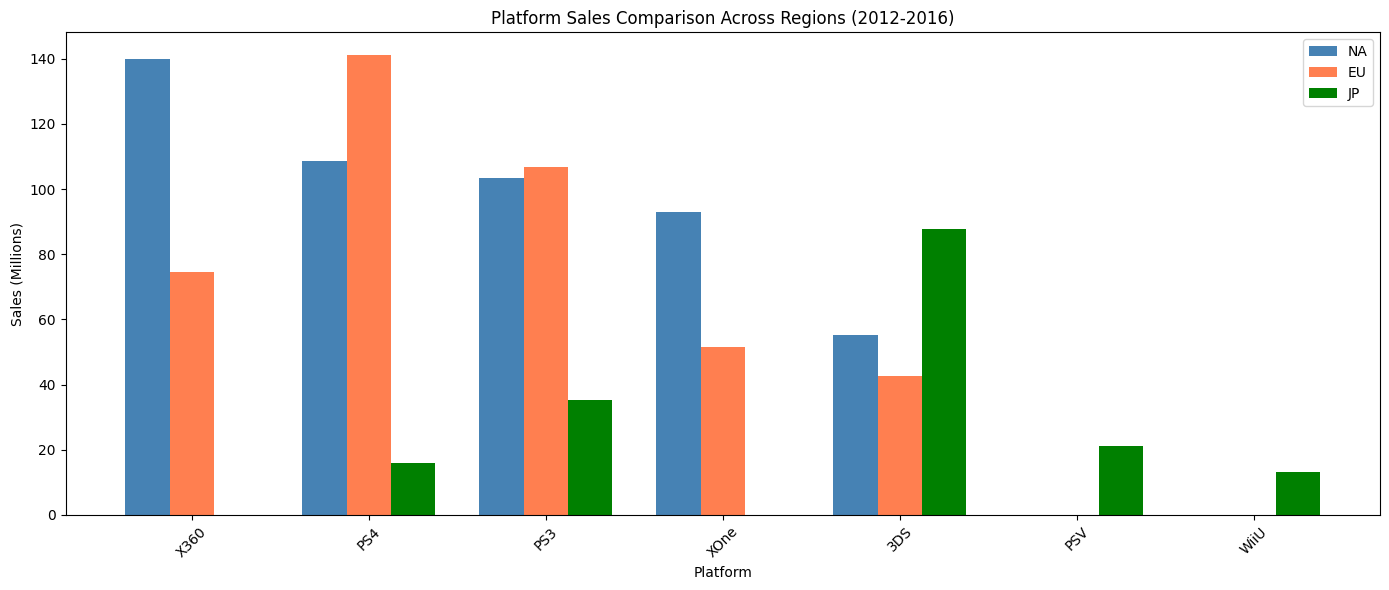

In [37]:
plt.figure(figsize=(14, 6))
regions = ['NA', 'EU', 'JP']
colors = ['steelblue', 'coral', 'green']


fig, ax = plt.subplots(figsize=(14, 6))
regions = ['NA', 'EU', 'JP']
colors = ['steelblue', 'coral', 'green']

all_platforms = combined['platform'].unique()
x = range(len(all_platforms))

for i, (region, color) in enumerate(zip(regions, colors)):
    region_data = combined[combined['region'] == region]
    sales_values = [region_data[region_data['platform'] == p]['sales'].values[0] 
                    if p in region_data['platform'].values else 0 
                    for p in all_platforms]
    ax.bar([pos + i * 0.25 for pos in x], sales_values, 
           width=0.25, label=region, color=color)

ax.set_xticks([pos + 0.25 for pos in x])
ax.set_xticklabels(all_platforms, rotation=45)
ax.set_title('Platform Sales Comparison Across Regions (2012-2016)')
ax.set_xlabel('Platform')
ax.set_ylabel('Sales (Millions)')
ax.legend()
plt.tight_layout()
plt.show()

Regional platform preferences vary significantly across markets. North America and Europe show similar preferences, with PS4 and Xbox One dominating — though NA shows stronger Xbox presence reflecting Western gaming culture. Japan tells a completely different story, heavily favoring Nintendo platforms like the 3DS, with Xbox having virtually no presence. This is consistent with real world knowledge — Sony and Nintendo are Japanese companies with strong domestic loyalty, and the Japanese market heavily favors genres like JRPGs and Nintendo-style games that Xbox historically underserves. These regional differences are critical for Ice when planning advertising campaigns — a one size fits all approach across regions would be ineffective.

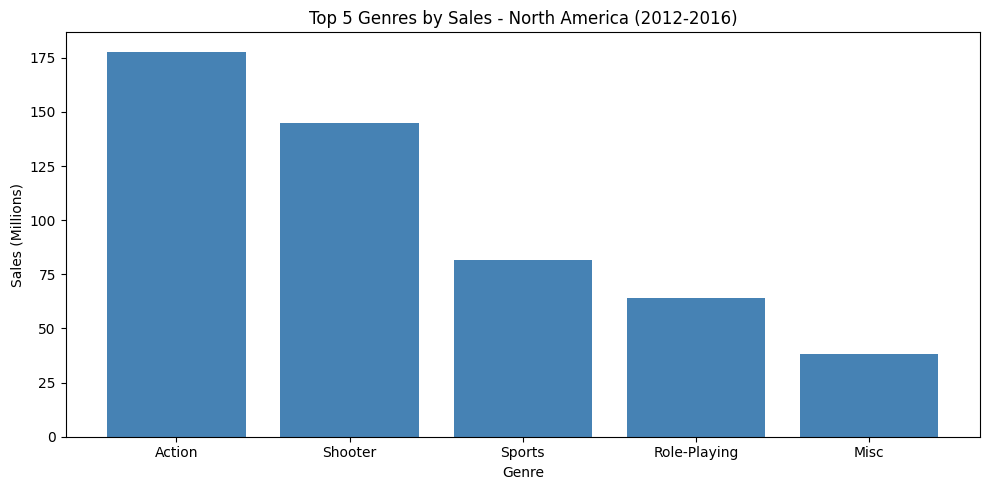


Top 5 genres in North America:
           genre   sales
0         Action  177.84
8        Shooter  144.77
10        Sports   81.53
7   Role-Playing   64.00
3           Misc   38.19


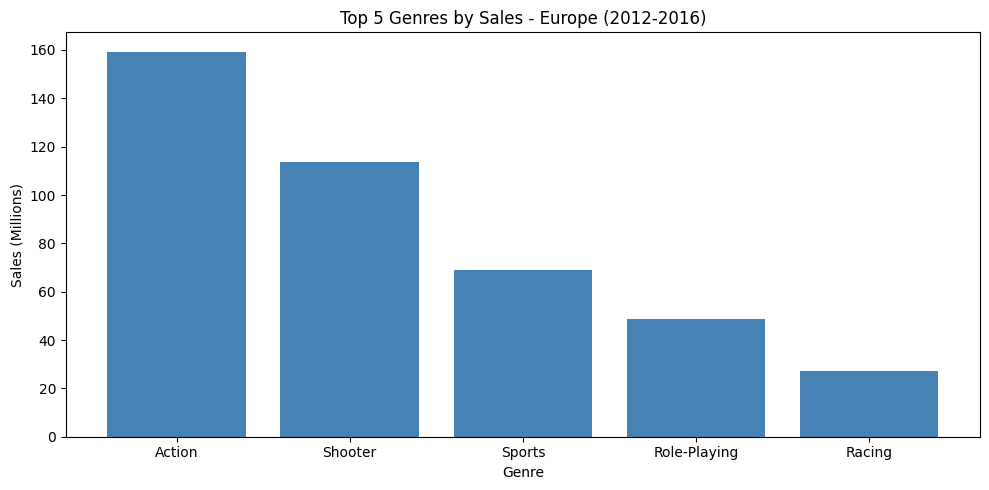


Top 5 genres in Europe:
           genre   sales
0         Action  159.34
8        Shooter  113.47
10        Sports   69.09
7   Role-Playing   48.53
6         Racing   27.29


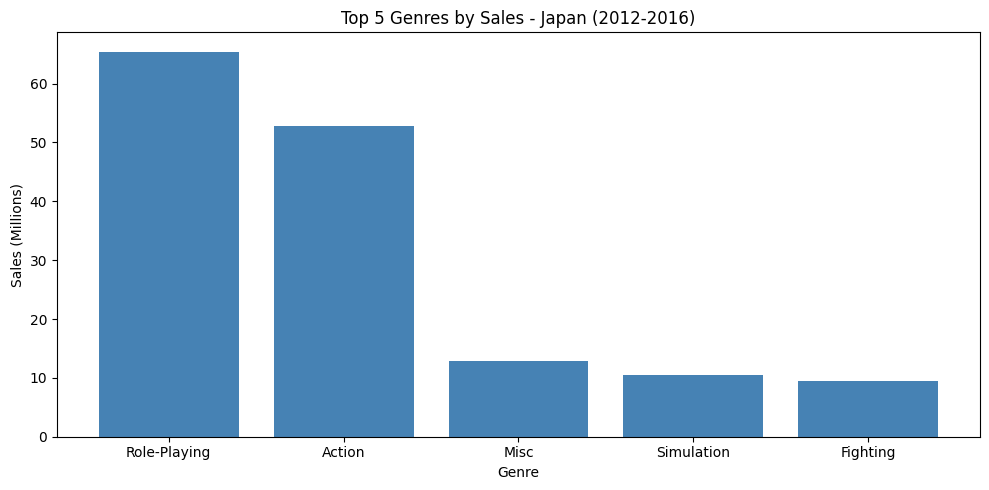


Top 5 genres in Japan:
          genre  sales
7  Role-Playing  65.44
0        Action  52.80
3          Misc  12.86
9    Simulation  10.41
2      Fighting   9.44


In [38]:
def analyze_region_genres(df, region_col, region_name, top_n=5):
    genre_sales = df.groupby('genre')[region_col].sum().reset_index()
    genre_sales.columns = ['genre', 'sales']
    genre_sales = genre_sales.sort_values('sales', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 5))
    plt.bar(genre_sales['genre'], genre_sales['sales'], color='steelblue')
    plt.title(f'Top {top_n} Genres by Sales - {region_name} (2012-2016)')
    plt.xlabel('Genre')
    plt.ylabel('Sales (Millions)')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop {top_n} genres in {region_name}:")
    print(genre_sales)
    return genre_sales


na_genres = analyze_region_genres(df_sales, 'na_sales', 'North America')
eu_genres = analyze_region_genres(df_sales, 'eu_sales', 'Europe')
jp_genres = analyze_region_genres(df_sales, 'jp_sales', 'Japan')

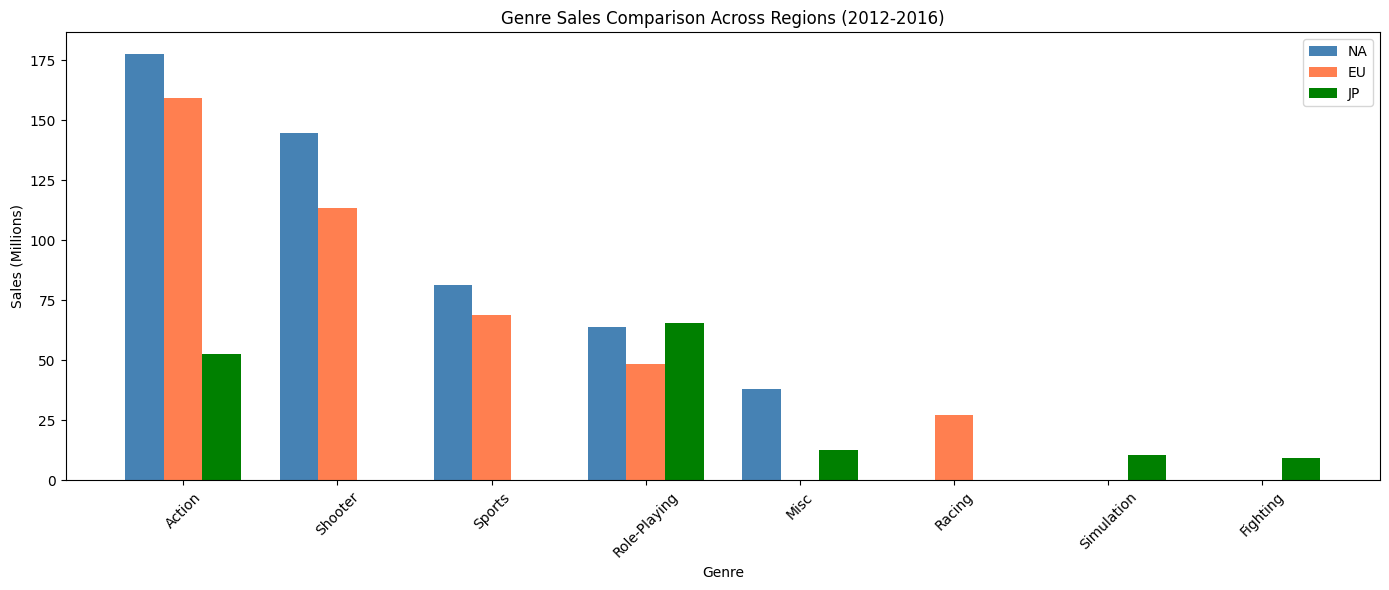

In [39]:
na_genres['region'] = 'NA'
eu_genres['region'] = 'EU'
jp_genres['region'] = 'JP'

combined_genres = pd.concat([na_genres, eu_genres, jp_genres])

fig, ax = plt.subplots(figsize=(14, 6))
regions = ['NA', 'EU', 'JP']
colors = ['steelblue', 'coral', 'green']

all_genres = combined_genres['genre'].unique()
x = range(len(all_genres))

for i, (region, color) in enumerate(zip(regions, colors)):
    region_data = combined_genres[combined_genres['region'] == region]
    sales_values = [region_data[region_data['genre'] == g]['sales'].values[0]
                    if g in region_data['genre'].values else 0
                    for g in all_genres]
    ax.bar([pos + i * 0.25 for pos in x], sales_values,
           width=0.25, label=region, color=color)

ax.set_xticks([pos + 0.25 for pos in x])
ax.set_xticklabels(all_genres, rotation=45)
ax.set_title('Genre Sales Comparison Across Regions (2012-2016)')
ax.set_xlabel('Genre')
ax.set_ylabel('Sales (Millions)')
ax.legend()
plt.tight_layout()
plt.show()

Japan's genre preferences diverge significantly from NA and EU. Role-Playing games rank highly reflecting the country's strong JRPG culture, while Sports games which dominate Western markets have virtually no presence. NA and EU share similar preferences with Action and Shooter genres leading, though EU shows stronger Sports sales driven by FIFA's massive European fanbase. These differences reinforce that regional advertising strategies should be tailored specifically to local tastes rather than applying a global approach.

In [40]:
def analyze_region_ratings(df, region_col, region_name):
    rating_sales = df.groupby('rating')[region_col].sum().reset_index()
    rating_sales.columns = ['rating', 'sales']
    rating_sales = rating_sales.sort_values('sales', ascending=False)
    
    plt.figure(figsize=(10, 5))
    plt.bar(rating_sales['rating'], rating_sales['sales'], color='steelblue')
    plt.title(f'Sales by ESRB Rating - {region_name} (2012-2016)')
    plt.xlabel('ESRB Rating')
    plt.ylabel('Sales (Millions)')
    plt.tight_layout()
    plt.show()
    
    print(f"\nSales by ESRB rating in {region_name}:")
    print(rating_sales)
    return rating_sales

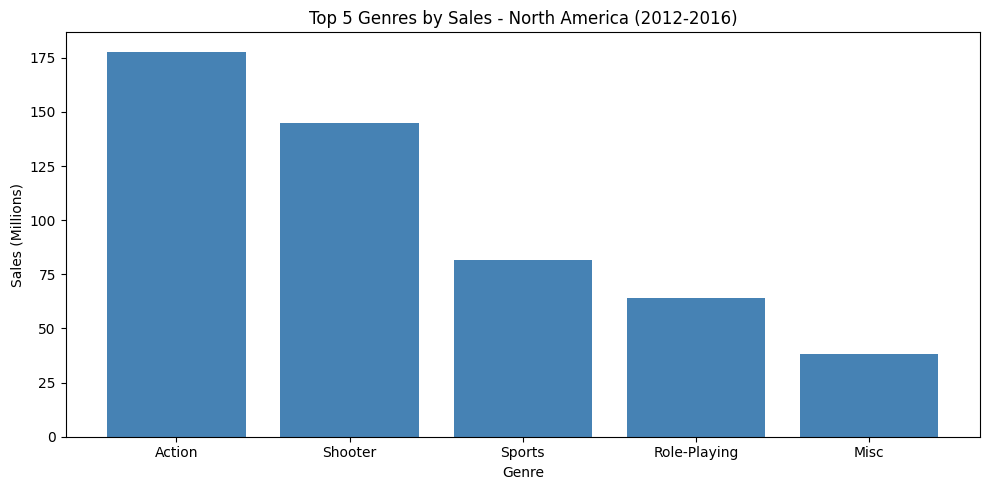


Top 5 genres in North America:
           genre   sales
0         Action  177.84
8        Shooter  144.77
10        Sports   81.53
7   Role-Playing   64.00
3           Misc   38.19


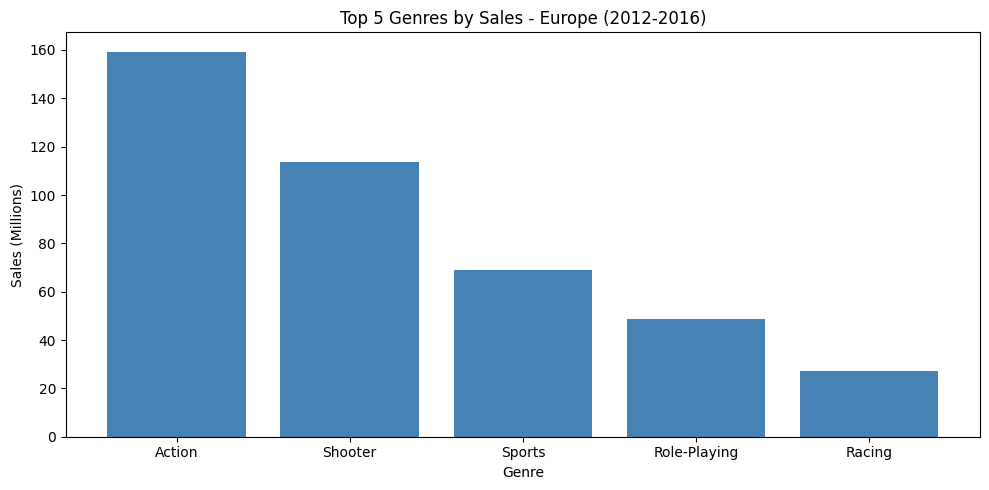


Top 5 genres in Europe:
           genre   sales
0         Action  159.34
8        Shooter  113.47
10        Sports   69.09
7   Role-Playing   48.53
6         Racing   27.29


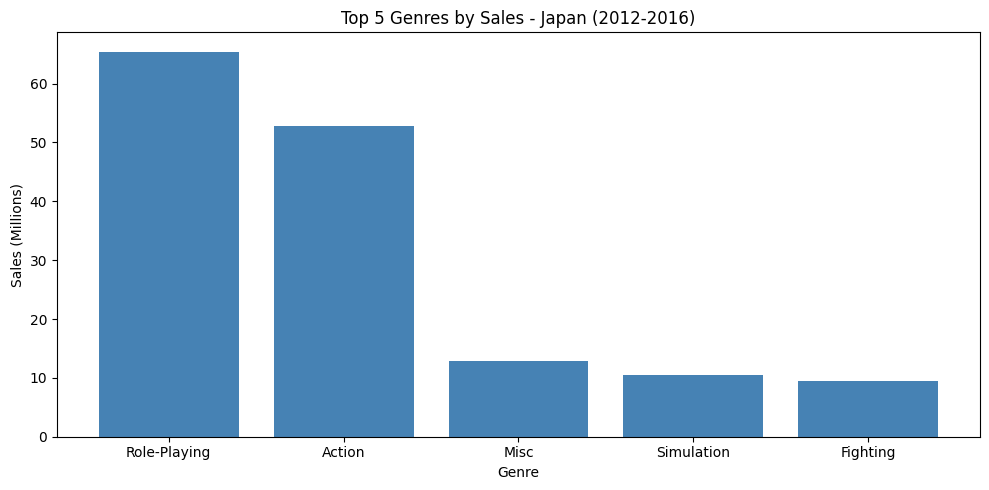


Top 5 genres in Japan:
          genre  sales
7  Role-Playing  65.44
0        Action  52.80
3          Misc  12.86
9    Simulation  10.41
2      Fighting   9.44


In [41]:
na_genres = analyze_region_genres(df_sales, 'na_sales', 'North America')
eu_genres = analyze_region_genres(df_sales, 'eu_sales', 'Europe')
jp_genres = analyze_region_genres(df_sales, 'jp_sales', 'Japan')

ESRB ratings impact sales differently across regions. North America shows M-rated games driving the highest revenue, consistent with the dominance of franchises like Call of Duty and GTA in the Western market. Europe follows a similar pattern though slightly more balanced across rating categories. Japan's numbers are significantly lower across all ESRB ratings — this is not indicative of lower overall sales, but rather reflects that Japan uses its own CERO rating system domestically. Many Japanese titles either lack ESRB ratings entirely or are inconsistently categorized, meaning our dataset significantly undercaptures the Japanese market. For Ice, ESRB ratings are most useful as a targeting tool in NA and EU markets where the rating system is consistently applied.

Hypothesis 1:

H₀ (null): The average user ratings of Xbox One and PC are equal
H₁ (alternative): The average user ratings of Xbox One and PC are not equal

Hypothesis 2:

H₀ (null): The average user ratings of Action and Sports genres are equal
H₁ (alternative): The average user ratings of Action and Sports genres are not equal

In [42]:
# Set our alpha threshold
alpha = 0.05

# Hypothesis 1: Average user ratings of Xbox One and PC are the same
xone_scores = df_reviewed[df_reviewed['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df_reviewed[df_reviewed['platform'] == 'PC']['user_score'].dropna()

print("Hypothesis 1: Xbox One vs PC User Ratings")
print(f"Xbox One - mean: {xone_scores.mean():.3f}, count: {len(xone_scores)}")
print(f"PC - mean: {pc_scores.mean():.3f}, count: {len(pc_scores)}")

results1 = st.ttest_ind(xone_scores, pc_scores, equal_var=False)
print(f"\nt-statistic: {results1.statistic:.3f}")
print(f"p-value: {results1.pvalue:.3f}")

if results1.pvalue < alpha:
    print("Result: We REJECT the null hypothesis - there is sufficient evidence the average user ratings are different")
else:
    print("Result: We FAIL TO REJECT the null hypothesis - there is insufficient evidence to conclude the averages are different")

print("\n" + "="*60 + "\n")

# Hypothesis 2: Average user ratings for Action and Sports genres are different
action_scores = df_reviewed[df_reviewed['genre'] == 'Action']['user_score'].dropna()
sports_scores = df_reviewed[df_reviewed['genre'] == 'Sports']['user_score'].dropna()

print("Hypothesis 2: Action vs Sports User Ratings")
print(f"Action - mean: {action_scores.mean():.3f}, count: {len(action_scores)}")
print(f"Sports - mean: {sports_scores.mean():.3f}, count: {len(sports_scores)}")

results2 = st.ttest_ind(action_scores, sports_scores, equal_var=False)
print(f"\nt-statistic: {results2.statistic:.3f}")
print(f"p-value: {results2.pvalue:.3f}")

if results2.pvalue < alpha:
    print("Result: We REJECT the null hypothesis - there is sufficient evidence the average user ratings are different")
else:
    print("Result: We FAIL TO REJECT the null hypothesis - there is insufficient evidence to conclude the averages are different")

Hypothesis 1: Xbox One vs PC User Ratings
Xbox One - mean: 6.493, count: 159
PC - mean: 6.358, count: 174

t-statistic: 0.813
p-value: 0.417
Result: We FAIL TO REJECT the null hypothesis - there is insufficient evidence to conclude the averages are different


Hypothesis 2: Action vs Sports User Ratings
Action - mean: 6.875, count: 422
Sports - mean: 5.816, count: 136

t-statistic: 7.701
p-value: 0.000
Result: We REJECT the null hypothesis - there is sufficient evidence the average user ratings are different


"We use Welch's t-test (equal_var=False) as we cannot assume equal variance between the two groups being compared.
1. For the first hypothesis, we used alpha value at .05 as that is the standard. We can assume that the reviews and ratings should be the same because Xbox and PC share a large amount of games. Microsoft has been pushing the play anywhere / play-pass ideology for years and this means that the gamepass library shares a lot of games. Thus, their reviews should be the same, which we did prove with our analysis.
2. I assumed that the user ratings of action and sports are not equal due to a large amount of facotrs. They are fundamentally different experiences with different player-bases. They also have different things affecting them, such as region, console availability, etc.

Throughout this analysis we set out to identify patterns that determine a game's success in order to help Ice plan their 2017 advertising campaigns. After cleaning and filtering our data to the most relevant period (2012-2016), several clear patterns emerged.
Platform matters enormously — PS4 and Xbox One are the dominant current generation platforms in Western markets and should be the primary focus for advertising. Nintendo's 3DS holds strong in Japan but Xbox has virtually no presence there, reinforcing that regional strategies cannot be one size fits all.
Genre preferences tell a similar regional story. Action and Shooter genres dominate NA and EU markets, while Japan heavily favors Role-Playing games. Sports games are a uniquely Western phenomenon driven by FIFA and Madden, with little relevance in the Japanese market.
Critic scores show a moderate positive correlation with sales (0.4) and are worth considering when deciding what to advertise. User scores however show virtually no correlation (-0.031) and should not be used as a predictor of commercial success — likely due to review timing, review bombing, and selection bias.
Our hypothesis tests confirmed that Xbox One and PC user ratings are statistically similar, likely reflecting their overlapping game libraries and player demographics. Action and Sports genre ratings are statistically different, consistent with their fundamentally different audiences and release patterns.
For Ice's 2017 campaign, the data suggests focusing advertising spend on PS4 and XOne titles in the Action, Shooter and Sports genres for NA and EU markets, while prioritizing Nintendo platforms and RPG titles for the Japanese market. Multi-platform releases represent lower inventory risk and broader revenue potential and should be stocked across all available platforms.
It is worth noting that this dataset captures physical sales only — digital distribution and mobile gaming represent significant blind spots that would likely change some conclusions if captured. The 2016 data is also incomplete and should be interpreted as a directional indicator rather than a full year of results.